# Zastosowanie uczenia maszynowego w rozpoznawaniu opinii gier komputerowych
*Uniwersytet WSB Merito Chorzów*

*Czerwiec 2026*

*Karol Wolski*

*Nr albumu: pcx22022*

## Wstęp

Celem projektu jest stworzenie algorytmu wykrywającego sentyment opinii gry napisanej w języku polskim, posługując się opiniami napisanymi w języku polskim opublikowanymi na platformie sprzedaży gier komputerowych Steam.

Kluczowymi problemami, który stawia sobie autor jest kwestia doboru próby do modelu a następnie wytrenowanie modelu na skrajnie . Głównym stawianym pytaniem jest jak z populacji milionów opinii wybrać małą próbę, która będzie w stanie wytrenować model o uniwersalnym zastosowaniu, niezależnie od popularności, gatunku czy stylu graficznego gry?

Największym utrudnieniem jest wysoka nierówność w liczebności klas. Opinii pozytywnych jest na Steam znacząco więcej niż negatywnych. Występują różnce powody wystawienia opinii negatywnej, które model będzie musiał umieć przewidywać. Dodatkowo język jaki jest używany w opiniach jest pełen błędów ortograficznych, slangu, wulgaryzmów i zapożyczeń z języków obcych, które model będzie musiał skurecznie interpretować.

Istotną częścią projektu jest pobieranie danych źródłowych. Opinie oraz informacje o grach zostały pozyskane samodzielnie z wykorzystaniem technik automatycznego pobierania danych z internetu.

Całość projektu jest wykonana z założeniem niskiej dostępności mocy obliczeniowej. Na cele projektu założono, że próba do tworzenia modelu uczenia maszynowego będzie się składać z 25 tysięcy elementów.

## Przegląd najpopularniejszych gier na platformie Steam

Steam ma przyjazne API dla scrapingu, jednak odnalezienie się w nim nie jest najprostsze. Nie ma punktu końcowego, z którego możnaby uzyskać listę najpopularniejszych gier z ilością opinii w języku polskim. Steam posiada listy 100 topowych gier wedle różnych projektów, ale na początku potrzebna jest dłuższa lista.

[SteamDB](https://steamdb.info/) jest darmową, niezależną bazą danych Steam. SteamDB po zalogowaniu pozwala na wyświetlenie list o wiele dłuższych niż 100 gier.

W celu wyboru odpowiednich gier autor kierował się [listą najpopularnieszych gier w maju 2026](https://steamdb.info/charts/?month=2026-05&sort=peak). Lista zawiera wszystkie gry, w które w szczytowym momencie maja 2026 grało co najmniej 100 osób. SteamDB zabrania scrapingu, dlatego autor ręcznie zapisał zawartość HTML strony w repozytorium.

Należy również podkreślić, że scraping danych został wykonany jedynie w celach edukacyjnych i nie będzie wykorzystywany komercyjnie.

In [4]:
import requests
# from bs4 import BeautifulSoup
import pandas as pd
import time
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [6]:
# Otwórz plik html 
with open('../data/steamdb_all_time_peak.html', 'r', encoding='utf-8') as file:
  steamdb_html = file.read()
steamdb_html_soup = BeautifulSoup(steamdb_html, 'html.parser')
print(steamdb_html_soup)


<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0, viewport-fit=cover" name="viewport"/>
<title>Steam Charts · Live Player Count Statistics in May 2026 · SteamDB</title>
<link href="https://shared.fastly.steamstatic.com/" rel="preconnect"/>
<link as="font" crossorigin="anonymous" href="/static/fonts/Inter-Regular.woff2?v=4.1" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="/static/fonts/Inter-Bold.woff2?v=4.1" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="/static/fonts/Inter-Italic.woff2?v=4.1" rel="preload" type="font/woff2"/>
<link href="/static/css/headcrab.css?v=97aeb4b2506e66f7" integrity="sha384-l660slBuZveyRNxdTuniZ819O7OdqIs2/gBijoib5q+xqkRBgZTFIzkij77Pa0tA" rel="stylesheet"/>
<link href="/static/css/charts.css?v=6fa7d7f292bd34c2" integrity="sha384-b6fX8pK9NMIdv+xzEg2H00csjI2KQAm8NWjB+aC3gcPgNDGuGqkXylJugZkB7YkN" rel="stylesheet"/>
<link href="h

In [7]:
# Podgląd nagłówków tabeli ze SteamDB
steamdb_html_thead = steamdb_html_soup.find('thead')
steamdb_headers = list(map(lambda th: th.get_text() ,steamdb_html_thead.find_all('th')))
print('Nagłówki tabeli SteamDB - ID gier nie jest widoczne jako tekst tabeli, ale jest dostępne w atrybutach.')
print(steamdb_headers)

Nagłówki tabeli SteamDB - ID gier nie jest widoczne jako tekst tabeli, ale jest dostępne w atrybutach.
['Rank', 'SteamDB.info', 'Name', 'Current', "May '26 Peak", 'All-Time Peak', ' ']


In [8]:
# Podgląd zawartości tabeli ze SteamDB - data-appid zawiera ID gry ze Steam
steamdb_html_tbody = steamdb_html_soup.find('tbody').find_all('tr')
print(f'Znaleziono {len(steamdb_html_tbody)} gier.\n')
print(steamdb_html_tbody)

Znaleziono 4161 gier.

[<tr class="app" data-appid="578080" data-capsule="14f42ab797699a9c9f137fda66582d8776da4330/capsule_231x87.jpg">
<td>1.</td>
<td class="applogo text-left"><a aria-hidden="true" href="/app/578080/charts/" tabindex="-1"><img alt="" src="/static/img/applogo.svg"/></a></td>
<td><a class="b" href="/app/578080/charts/">PUBG: BATTLEGROUNDS</a></td>
<td data-sort="277031">277,031</td>
<td data-sort="822514">822,514</td>
<td data-sort="3257248">3,257,248</td>
<td class="add">+</td>
</tr>, <tr class="app" data-appid="2358720" data-capsule="b7f722ddd5e23503f598586aa3700dd4d827bb2d/capsule_231x87.jpg">
<td>2.</td>
<td class="applogo text-left"><a aria-hidden="true" href="/app/2358720/charts/" tabindex="-1"><img alt="" src="/static/img/applogo.svg"/></a></td>
<td><a class="b" href="/app/2358720/charts/">Black Myth: Wukong</a></td>
<td data-sort="7713">7,713</td>
<td data-sort="16286">16,286</td>
<td data-sort="2415714">2,415,714</td>
<td class="add">+</td>
</tr>, <tr class="a

In [9]:
steamdb_parsed = []

for tr in steamdb_html_tbody:
  steam_id = tr.get('data-appid')

  tds = tr.find_all('td')
  if len(tds) == 7:
    steam_name = tds[2].get_text()
    all_time_peak = int(tds[5].get('data-sort'))

  steamdb_parsed.append({
    'steam_id': steam_id,
    'name': steam_name,
    'all-time_peak': all_time_peak
  })

df_steamdb = pd.DataFrame(steamdb_parsed)
print(df_steamdb)

     steam_id                                  name  all-time_peak
0      578080                   PUBG: BATTLEGROUNDS        3257248
1     2358720                    Black Myth: Wukong        2415714
2     1623730                              Palworld        2101867
3         730                      Counter-Strike 2        1862531
4     2246340                  Monster Hunter Wilds        1384608
...       ...                                   ...            ...
4156  1988540  The Zachtronics Solitaire Collection            128
4157  3689850             Final War: Frozen Defense            128
4158  3515100                                  OCCT            127
4159  2505570                         Burger Shop 3            123
4160  2485190            MediBang Paint for Desktop            121

[4161 rows x 3 columns]


## Wzbogacenie listy popularnych gier o statystyki recenzji

Przy potrzebnej wielkości populacji do uczenia maszynowego, planem jest skupienie się na grach, które mają co najmniej 100 opinii. W późniejszym etapie Steam będzie pozwalał na pobranie opinii w paczkach o maksymalnym rozmiarze 100 opinii. Dlatego, żeby nie generować zbyt wielu zapytań do serwera Steam, celem analizy jest skupienie się na grach, które będą zwracać co najmniej jedną pełną paczkę. Ilość opinii zawsze będzie znacząco niższa od ilości graczy, dlatego dla uproszczenia poddane zostaną analizie gry o szczytowej popularności powyżej 5000 graczy.

In [10]:
# Przygotowanie pod późniejsze uzupełnienie danych
df_steamdb_popular = df_steamdb[df_steamdb['all-time_peak'] > 5000]
df_steamdb_popular['total_reviews'] = np.nan
df_steamdb_popular['total_positive'] = np.nan
df_steamdb_popular['total_negative'] = np.nan
df_steamdb_popular['percent_positive'] = np.nan
df_steamdb_popular['review_score'] = np.nan
df_steamdb_popular['review_score_desc'] = ''
print(df_steamdb_popular)

print('\n\nZapisywanie do pliku CSV...')
stats_path = '../data/steam_stats.csv'
id_col_name = 'steam_id'

# Załadowanie listy istniejących ID - użyto set() bo ma złożoność czasową O(1)
if os.path.exists(stats_path):
  df_existing_stats = pd.read_csv(stats_path, usecols=[id_col_name])
  existing_ids = set(df_existing_stats[id_col_name].astype(str))
else:
  existing_ids = set()

new_apps = df_steamdb_popular[
    ~df_steamdb_popular[id_col_name].isin(existing_ids)
]

# Zapis nowych danych - jeśli plik nie istnieje dodatkowo zapisane nagłówki.
if new_apps.shape[0] > 0:
    header_required = not os.path.exists(stats_path)
    
    new_apps.to_csv(stats_path, mode='a', header=header_required, index=False)
    print(f'Dodano {len(new_apps)} nowych gier.')
else:
    print('Brak nowych gier.')

     steam_id                                  name  all-time_peak  \
0      578080                   PUBG: BATTLEGROUNDS        3257248   
1     2358720                    Black Myth: Wukong        2415714   
2     1623730                              Palworld        2101867   
3         730                      Counter-Strike 2        1862531   
4     2246340                  Monster Hunter Wilds        1384608   
...       ...                                   ...            ...   
1736   435120                      Rusty Lake Hotel           5038   
1737   418240  Shadow Tactics: Blades of the Shogun           5037   
1738   407130               Tank Mechanic Simulator           5022   
1739    21970                               R.U.S.E           5018   
1740   822240                            Animal Jam           5009   

      total_reviews  total_positive  total_negative  percent_positive  \
0               NaN             NaN             NaN               NaN   
1            

Dla powyższych gier zostaje przeprowadzony scraping z oficjalnych serwerów Steam. Dla każdej z gier potrzebna jest informacja o łącznej ilości opinii w języku polskim oraz średnim wyniku recenzji. Aby przypadkowo nie uruchomić ponownie ponad 1500 zapytań do Steam została dodana flaga `overwrite_stats`, która decyduje o tym, czy zostaną nadpisane informacje o recencjach dla gry, która już takie informacje posiada.

In [11]:
def get_game_review_stats(stats_path_output, overwrite_stats=False):
  try:
    df_apps = pd.read_csv(stats_path_output)
  except Exception:
    try:
      df_steamdb_popular.iloc[0:0].to_csv('../data/test_save.csv', mode='x', index=False)
    except Exception as e:
      sys.exit(f'Wystąpił problem z utworzeniem pliku docelowego: {e}')

  rate_limit_hits = 0
  max_rate_hits = 5
  initial_sleep = 2
  
  # Kopia do pracy
  df_apps_processing = df_apps.astype({'review_score_desc':str})
  
  # Jeśli nadpisujemy, zerujemy kolumny w kopii
  if overwrite_stats:
    df_apps_processing['total_reviews'] = np.nan
    df_apps_processing['total_positive'] = np.nan
    df_apps_processing['total_negative'] = np.nan
    df_apps_processing['percent_positive'] = np.nan
    df_apps_processing['review_score'] = np.nan
    df_apps_processing['review_score_desc'] = ''

  headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
  }
  params = {
    'json': 1,
    'purchase_type': 'all',
    'l': 'polish'
  }

  # Liczymy wiersze, które mają braki w 'total_reviews'
  missing_data_mask = df_apps_processing['total_reviews'].isna()
  total_to_process = missing_data_mask.sum()
  print(f'Znaleziono {total_to_process} gier do uzupełnienia.')

  # Iteracja po ramce danych
  for idx, row in enumerate(df_apps_processing.itertuples(), 1):
      
    # Sprawdzamy czy dla danego wiersza brakuje danych (Total Reviews jest NaN)
    if pd.isna(getattr(row, 'total_reviews', np.nan)):
      app_id = getattr(row, 'steam_id') # Zakładam, że kolumna ID to 'steam_id'
      print(f'[{idx}/{total_to_process}] Pobieranie dla ID: {app_id}...')
      url = f'https://store.steampowered.com/appreviews/{app_id}'
      
      try:
        response = requests.get(url, headers=headers, params=params, timeout=10)

        # Obsługa rate limit (HTTP 429)
        while response.status_code == 429:
          if rate_limit_hits < max_rate_hits:
            rate_limit_hits += 1
            sleep_time = initial_sleep * (2 ** rate_limit_hits)
            print(f'STOP! Wykryto rate limit! Zasypiam na {sleep_time} sekund...')
            time.sleep(sleep_time)
            response = requests.get(url, headers=headers, params=params, timeout=10)
          else:
            # Zapisujemy dotychczasowy postęp przed awaryjnym wyjściem
            df_apps_processing.to_csv(stats_path_output, mode='w', index=False)
            sys.exit('Przekroczono maksymalną liczbę prób rate limit!')

        if response.status_code == 200:
          data = response.json()

          if data.get('success') == 1 and 'query_summary' in data:
            summary = data['query_summary']
            total_reviews = summary.get('total_reviews', 0)
            total_positive = summary.get('total_positive', 0)
            total_negative = summary.get('total_negative', 0)
            review_score = summary.get('review_score', 0)
            review_score_desc = summary.get('review_score_desc', 'Brak')

            percent_positive = (
              (total_positive / total_reviews) * 100
              if total_reviews > 0 else 0.0
            )

            # Bezpośredni zapis do kopii DataFrame za pomocą .at
            row_idx = row.Index
            df_apps_processing.at[row_idx, 'total_reviews'] = total_reviews
            df_apps_processing.at[row_idx, 'total_positive'] = total_positive
            df_apps_processing.at[row_idx, 'total_negative'] = total_negative
            df_apps_processing.at[row_idx, 'percent_positive'] = percent_positive
            df_apps_processing.at[row_idx, 'review_score'] = review_score
            df_apps_processing.at[row_idx, 'review_score_desc'] = review_score_desc
          else:
            print(f'Brak sekcji query_summary lub błąd sukcesu dla ID {app_id}')
        else:
          print(f'Błąd HTTP {response.status_code} dla ID {app_id}')

      except Exception as e:
        print(f'Nieoczekiwany błąd przy ID {app_id}: {e}')

  # Zapis całego zmodyfikowanego DataFrame na dysk po zakończeniu pętli
  df_apps_processing.to_csv(stats_path_output, mode='w', index=False)
  print("Zakończono pobieranie. Zaktualizowano plik CSV.")
  
  return df_apps_processing

In [ ]:
# Pobieranie zajęło 27 min 42 s
get_game_review_stats(stats_path)

Znaleziono 1741 gier do uzupełnienia.
[1/1741] Pobieranie dla ID: 578080...
[2/1741] Pobieranie dla ID: 2358720...
[3/1741] Pobieranie dla ID: 1623730...
[4/1741] Pobieranie dla ID: 730...
[5/1741] Pobieranie dla ID: 2246340...
[6/1741] Pobieranie dla ID: 1599340...
[7/1741] Pobieranie dla ID: 570...
[8/1741] Pobieranie dla ID: 1091500...
[9/1741] Pobieranie dla ID: 1245620...
[10/1741] Pobieranie dla ID: 2923300...
[11/1741] Pobieranie dla ID: 1063730...
[12/1741] Pobieranie dla ID: 990080...
[13/1741] Pobieranie dla ID: 1086940...
[14/1741] Pobieranie dla ID: 2807960...
[15/1741] Pobieranie dla ID: 1568590...
[16/1741] Pobieranie dla ID: 2767030...
[17/1741] Pobieranie dla ID: 1172470...
[18/1741] Pobieranie dla ID: 1030300...
[19/1741] Pobieranie dla ID: 2694490...
[20/1741] Pobieranie dla ID: 2868840...
[21/1741] Pobieranie dla ID: 892970...
[22/1741] Pobieranie dla ID: 1938090...
[23/1741] Pobieranie dla ID: 105600...
[24/1741] Pobieranie dla ID: 1515950...
[25/1741] Pobieranie dl

,steam_id,name,all-time_peak,total_reviews,total_positive,total_negative,percent_positive,review_score,review_score_desc
0,578080,PUBG: BATTLEGROUNDS,3257248,17883.0,13707.0,4176.0,76.65,6.0,W większości pozytywne
1,2358720,Black Myth: Wukong,2415714,2080.0,1937.0,143.0,93.12,8.0,Bardzo pozytywne
2,1623730,Palworld,2101867,2261.0,2174.0,87.0,96.15,9.0,Przytłaczająco pozytywne
3,730,Counter-Strike 2,1862531,502009.0,437569.0,64440.0,87.16,8.0,Bardzo pozytywne
4,2246340,Monster Hunter Wilds,1384608,806.0,561.0,245.0,69.60,5.0,Mieszane
...,...,...,...,...,...,...,...,...,...
1736,435120,Rusty Lake Hotel,5038,204.0,198.0,6.0,97.06,8.0,Bardzo pozytywne
1737,418240,Shadow Tactics: Blades of the Shogun,5037,494.0,479.0,15.0,96.96,8.0,Bardzo pozytywne
1738,407130,Tank Mechanic Simulator,5022,445.0,401.0,44.0,90.11,8.0,Bardzo pozytywne
1739,21970,R.U.S.E,5018,126.0,122.0,4.0,96.83,8.0,Bardzo pozytywne


## Wstępna analiza statystyk recenzji gier

W poprzedniej sekcji tatystyki gier zostały pomyślnie pobrane. W następnych krokach zostanie przeprowadzona analiza w celu oceny najbardziej optymalnego wyboru próby gier i opinii do optymalnego wytrenowania modelu uczenia maszynowego.

In [23]:
df_steam_stats = pd.read_csv(stats_path)
df_stats_desc = df_steam_stats.describe()
stats_count_with_na = len(df_steam_stats)

df_stats_desc[list(df_stats_desc.columns)] = df_stats_desc[list(df_stats_desc.columns)].round(0).astype(int)
print(df_stats_desc)
print('='*75)
print(f'Łączna liczba recenzji: {int(df_steam_stats['total_reviews'].sum())}')
print(f'Liczba pozytywnych recenzji: {int(df_steam_stats['total_positive'].sum())}')
print(f'Liczba negatywnych recenzji: {int(df_steam_stats['total_negative'].sum())}')

       steam_id  all-time_peak  total_reviews  total_positive  total_negative  \
count      1741           1741           1741            1741            1741   
mean    1370892          52458           1811            1637             173   
std     1067996         157756          12729           11198            1587   
min          10           5009              0               0               0   
25%      431960           8164             64              54               6   
50%     1151340          15141            318             274              33   
75%     2134320          39524           1212            1069             103   
max     4750320        3257248         502009          437569           64440   

       percent_positive  review_score  
count              1741          1741  
mean                 83             7  
std                  22             3  
min                   0             0  
25%                  80             6  
50%                  90       

Z powyższych statystyk wynika wstępnie można założyć, że zbiór danych jest dobrej jakości. Nie widać żadnych braków w danych ani wartości nielogicznych (np. procent opinii pozytywnych powyżej 100%).

Gdyby wystąpiły braki należałoby się cofnąć do kroku z funkcją `get_game_review_stats` Chociaż funkcja posiada obsługę błędów, lista nie jest w pełni kompletna. Steam API może w wyjątkowych sytuacjach zwrócić kod odpowiedzi "200" i flagę success "1", a mimo to nie zawierać poszukiwanych informacji. Autor tylko raz miał taką sytuację przy testowaniu funkcji i to tylko na jednej z 1741 gier.

In [24]:
# Analiza przedziałów pozytywnych ocen po decylach
# Na wszelki wypadek usuwane są wiersze z brakami, gdyby takie występowały

df_steam_stats_clean = df_steam_stats.dropna()
stats_count_without_na = len(df_steam_stats_clean)
print(f'Usunięto {int(stats_count_with_na - stats_count_without_na)} gier z analizy, ze względu na brak danych.')
# + 1 po to żeby decyle były od 1 do 10 zamiast od 0 do 9
df_steam_stats_clean['decile'] = pd.qcut(df_steam_stats_clean['percent_positive'], q=10, labels=False, duplicates='drop') + 1

df_stats_decile_agg = df_steam_stats_clean.groupby('decile').agg(
  range_min=('percent_positive', 'min'),
  range_max=('percent_positive', 'max'),
  avg_peak=('all-time_peak', 'mean'),
  avg_total_reviews=('total_reviews', 'mean'),
  avg_positive=('total_positive', 'mean'),
  avg_negative=('total_negative', 'mean')
).reset_index()

# Formatowanie kolumn
stats_to_round = ['avg_peak', 'avg_total_reviews', 'avg_positive', 'avg_negative']
df_stats_decile_agg[stats_to_round] = df_stats_decile_agg[stats_to_round].round(0).astype(int)
df_stats_decile_agg['Przedział ocen (%)'] = df_stats_decile_agg.apply(
  lambda row: f"{row['range_min']:.1f}% - {row['range_max']:.1f}%", axis=1
)

# Selekcja i zmiana nazw kolumn do tabeli
df_stats_decile_final = df_stats_decile_agg[[
    'decile', 'Przedział ocen (%)', 'avg_peak', 'avg_total_reviews', 'avg_positive', 'avg_negative'
]].rename(columns={
    'decile': 'Decyl',
    'avg_peak': 'Średni Peak Graczy',
    'avg_total_reviews': 'Średnia ilość opinii',
    'avg_positive': 'Średnie opinie (+)',
    'avg_negative': 'Średnie opinie (-)'
})

# Wyświetlenie tabeli
print(df_stats_decile_final.to_string(index=False))

Usunięto 0 gier z analizy, ze względu na brak danych.
 Decyl Przedział ocen (%)  Średni Peak Graczy  Średnia ilość opinii  Średnie opinie (+)  Średnie opinie (-)
     1       0.0% - 61.9%               39434                   246                 133                 113
     2      62.1% - 76.4%               60913                   693                 486                 207
     3      76.5% - 82.7%               70041                  1079                 861                 218
     4      82.7% - 87.2%               44191                  1289                1095                 194
     5      87.2% - 90.4%               55072                  4055                3556                 498
     6      90.5% - 92.7%               56485                  1893                1733                 160
     7      92.7% - 94.5%               57463                  2223                2081                 142
     8      94.6% - 96.2%               57101                  1867               

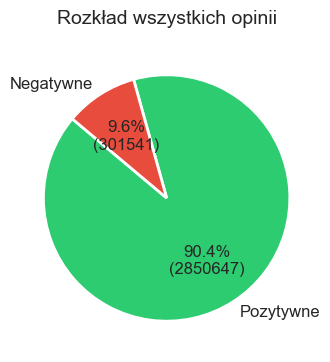

In [25]:
# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Funkcja do formatowania etyiet wykresów kołowych
def make_autopct(values):
  def my_autopct(pct):
    total = sum(values)
    val = int(round(pct * total / 100.0))
    return '{p:.1f}%\n({v:d})'.format(p=pct, v=val)
  return my_autopct

#### Wykres kołowy P/N ###
plt.figure(figsize=(4, 4))

total_positive = df_steam_stats_clean['total_positive'].sum()
total_negative = df_steam_stats_clean['total_negative'].sum()

labels = ['Pozytywne', 'Negatywne']
sizes = [total_positive, total_negative]
colors = ['#2ecc71', "#e74c3c"]

plt.pie(
  sizes, 
  labels=labels, 
  autopct=make_autopct(sizes),
  startangle=140, 
  colors=colors, 
  textprops={'fontsize': 12},
  wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Rozkład wszystkich opinii', fontsize=14, pad=15)
plt.show()

Wstępna analiza od razu pokazuje, że pozytywnych opini jest znacząco więcej od negatywnych. Patrząc na rozkład procentu opinii pozytywnych widać, że pierwszy decyl jest od 0 aż do 61.9%, natomiast mediana to aż 90%. Wyjaśnień takich statystyk może być kilka. Jednym wyjaśnieniem może być świadomość zakupowa graczy, czyli gracze mimo bardzo przyjaznej polityki zwrotów Steam decydują się na zakup gry tylko jeśli są w dużym stopniu przekonani, że gra im się spodoba. Może to też oznaczać, że gracze z zasady nie chcą zostawiać grom złych opinii, żeby nie zniechęcać deweloperów od próbawania nowych pomysłów, które często mogą nie być całkowicie udane. Zjawisko tzw. "review-bombing", byłoby przykładem odwrotnego zachowania, gdzie gracze każą deweloperów falą negatywnych opinii, za zbytnią chciwość lub lenistwo dewelopera. Jak jednać widać po rozkładzie klas znacząco przeważają pozytywne emocje przy wystawianiu recenzji.

Ponadto z wykresu kołowego można odczytać, że łącznie dla badanych gier istnieje ponad 3 miliony opinii. Jest to stanowczo za dużo na potrzeby tego projektu. Potrzebna jest przemyślana strategia próbkowania, aby zbudować uniwersalny model. Problem próbkowania zostanie podzielony na dwie części. Po pierwsze dobór gier do próby, a kolejno dobór opinii z każdej z wybranych gier.


## Dobór metody próbkowania gier
Jednym z możliwych podejść do próbkowania gier byłby wybór po klasyfikacji ocen Steam. Steam każdej grze przypisuje liczbowy kod oraz opis kodu klasyfikacji ocen gry. W analizowanym zbiorze kod znajduje się w kolumnie `review_score`, a opis kodu w `review_score_desc`. Klasyfikacja odpowiada procentowi opinii pozytywnych oraz łącznej liczbie ocen, zgodnie z poniższym wykresem przygotowanym przez użytkownika @runevision i opublikowanym na serwisie internetowym Reddit.

![Steam review scores](/assets/steam_reviews_chart.png)

Innym sposobem byłoby podzielenie populacji na równe części samodzielnie wyłącznie po procencie opinii pozytywnych. Przykładowo populację można podzielić na decyle sortując po procencie pozytywnych opinii. Różnicą względem klasyfikacji Steam jest zignorowanie ilości opinii przy doborze próby gier. Aspekt ilości recenzji ma znaczenie dla trenowania modelu w kontekście minimalizacji zapytań do Steam API, ale w kontekście merytorycznym najważniejsze jest uzyskanie próby o odpowiednio wysokiej liczebności opinii negatywnych.

Autor w dalszej części skupi się na ocenie tych dwóch podejść i wyborze najlepszego z nich.

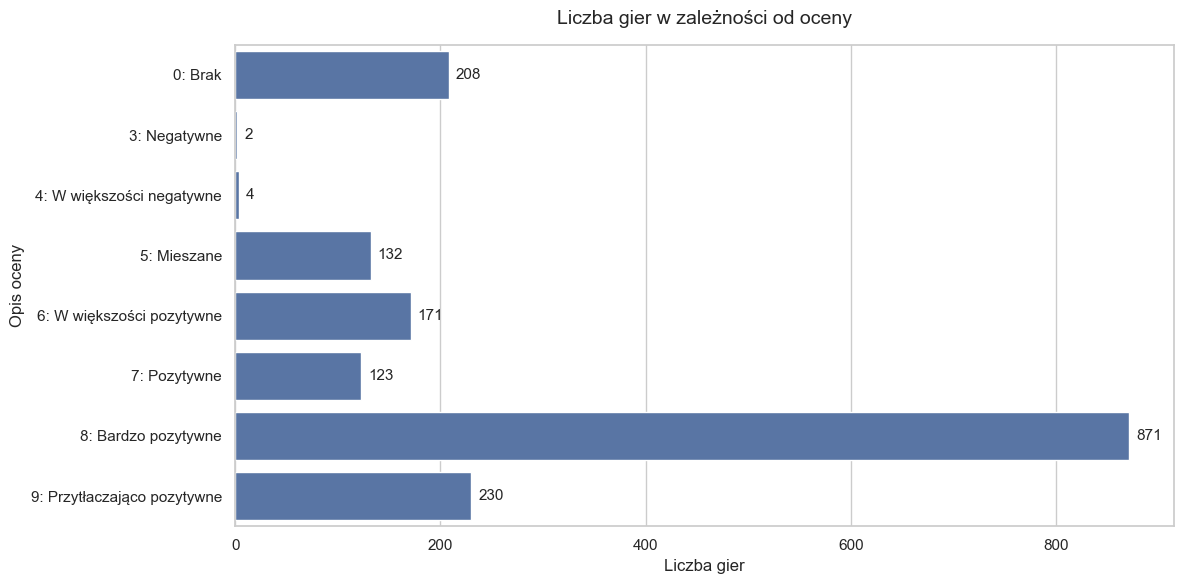

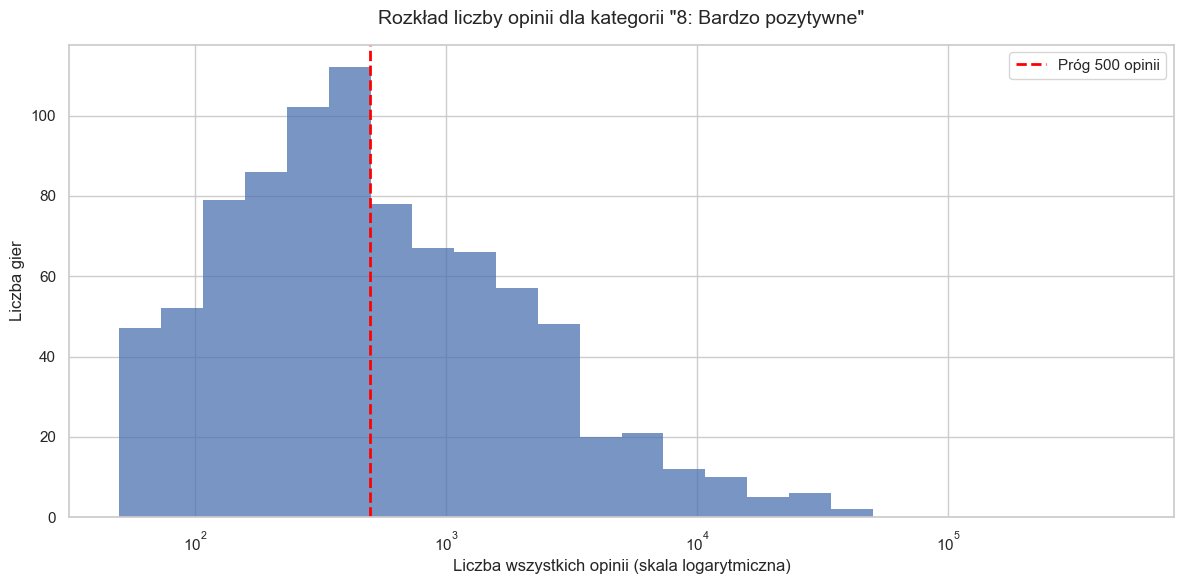

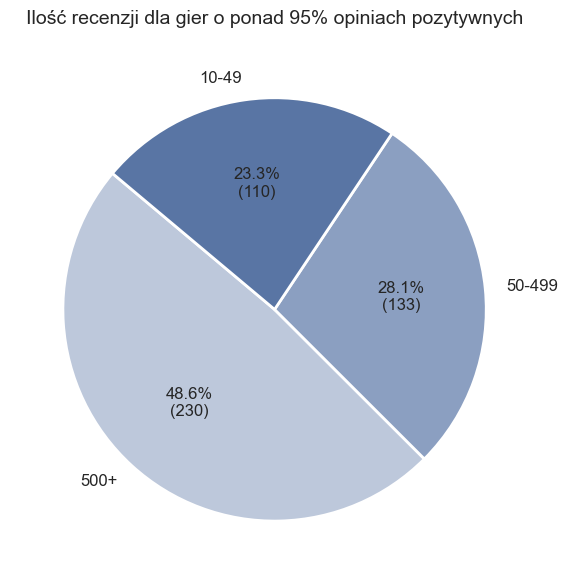

In [26]:
# Dodanie kolumny z odpowiednimi wartościami pod opis osi
review_score_str = df_steam_stats_clean['review_score'].astype(int).astype(str)
review_score_desc_str = np.where(df_steam_stats_clean['review_score'] == 0.0, 'Brak', df_steam_stats_clean['review_score_desc'])
df_steam_stats_clean['review_label'] = review_score_str + ': ' + review_score_desc_str.astype(str)

### Wykres słupkowy ###
plt.figure(figsize=(12,6))

cp_bar_order = sorted([str(x) for x in df_steam_stats_clean['review_label'].unique()])
revew_label_cplot = sns.countplot(data=df_steam_stats_clean, y='review_label', order=cp_bar_order)

revew_label_cplot.bar_label(revew_label_cplot.containers[0], padding=5, fontsize=11)
plt.title('Liczba gier w zależności od oceny', fontsize=14, pad=15) # pad,żeby tytuł nie był tak blisko wykresu
plt.xlabel('Liczba gier', fontsize=12)
plt.ylabel('Opis oceny', fontsize=12)

plt.tight_layout()
plt.show()

### Histogram opinii bardzo pozytywnych ###
df_stats_very_positive = df_steam_stats_clean[df_steam_stats_clean['review_label'] == '8: Bardzo pozytywne']

# Stworzenie przedziałów (bins) rozmieszczonych logarytmicznie
min_val_vp = df_stats_very_positive['total_reviews'].min()
max_val_vp = df_stats_very_positive['total_reviews'].max()
log_bins = np.logspace(np.log10(min_val_vp), np.log10(max_val_vp), 25)

plt.figure(figsize=(12, 6))
sns.histplot(
  data=df_stats_very_positive, 
  x='total_reviews', 
  bins=log_bins
)

# Ustawienie osi X w skali logarytmicznej
plt.xscale('log')
plt.axvline(x=500, color='red', linestyle='--', linewidth=2, label='Próg 500 opinii')

plt.title('Rozkład liczby opinii dla kategorii "8: Bardzo pozytywne"', fontsize=14, pad=15)
plt.xlabel('Liczba wszystkich opinii (skala logarytmiczna)', fontsize=12)
plt.ylabel('Liczba gier', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

#### Wykres kołowy >= 95% ###
df_stats_above_95 = df_steam_stats_clean[df_steam_stats_clean['percent_positive'] >= 95]
plt.figure(figsize=(6, 6))

review_count_l = len(df_stats_above_95[df_stats_above_95['total_reviews'] >= 500])
review_count_m = len(df_stats_above_95[(df_stats_above_95['total_reviews'] >= 50) & (df_stats_above_95['total_reviews'] < 500)])
review_count_s = len(df_stats_above_95[df_stats_above_95['total_reviews'] < 50])

labels = ['500+', '50-499', '10-49']
sizes = [review_count_l, review_count_m ,review_count_s]
colors = ["#bdc8db", "#8b9fc1", "#5975a4"]

# Rysowanie wykresu
plt.pie(
  sizes, 
  labels=labels, 
  autopct=make_autopct(sizes), # Wywołanie naszej funkcji
  startangle=140, 
  colors=colors, 
  textprops={'fontsize': 12},
  wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Ilość recenzji dla gier o ponad 95% opiniach pozytywnych', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Dalsza analiza pokazuje, że w zbiorze dominuje kategoria "8: Bardzo pozytywnie". Dominacja tej grupy jest częściowo wzmocniona systemem ocen Steam. Gra może otrzymać ocenę "9: Przytłaczająco pozytywne" tylko jeśli posiada 500 lub więcej opinii. Stąd na powyższym histogramie widać znaczący spadek gęstości na granicy tylu opinii. Dodatkowo aż 110 ze 123 gier w kategorii "7: Pozytywne" miało ponad 95% pozytywnych opinii.

Powyższa analiza pokazała, że dobór po klasach przypisanych przez Steam nie jest najlepszym podejściem. Przy najwyższych 3 klasach to parametr ilości opinii jest kluczowym kryterium przydziału, a nie procent opinii pozytywnych. Losując próbę po klasyfikacji Steam mogłoby się okazać że połowa wybranych gier ma ponad 95% pozytywnych opinii, co pogorszyłoby zdolności predykcyjne modelu.

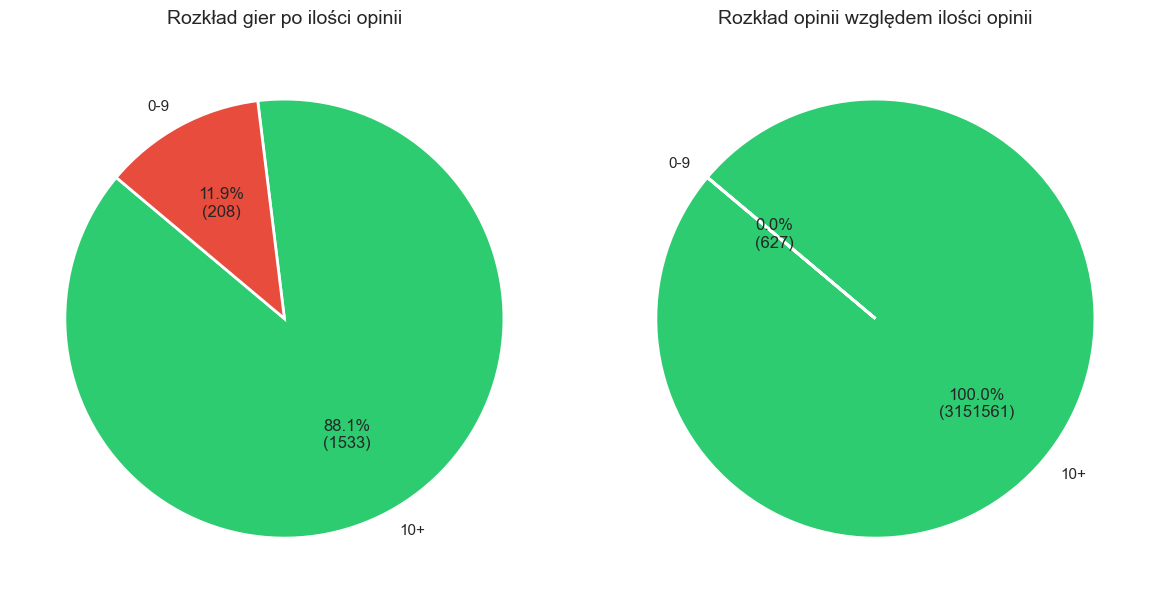

In [27]:
### Wykresy kołowe - ilość opinii
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Dane
total_games_popular = df_steam_stats_clean[df_steam_stats_clean['review_score'] != 0]['total_reviews'].count()
total_games_not_popular = df_steam_stats_clean[df_steam_stats_clean['review_score'] == 0]['total_reviews'].count()

total_reviews_popular = df_steam_stats_clean[df_steam_stats_clean['review_score'] != 0]['total_reviews'].sum()
total_reviews_not_popular = df_steam_stats_clean[df_steam_stats_clean['review_score'] == 0]['total_reviews'].sum()

colors = ['#2ecc71', "#e74c3c"]
labels = ['10+', '0-9']

# Wykresy
ax1.pie([total_games_popular, total_games_not_popular], labels=labels, autopct=make_autopct([total_games_popular, total_games_not_popular]), 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Rozkład gier po ilości opinii', fontsize=14, pad=15)

ax2.pie([total_reviews_popular, total_reviews_not_popular], labels=labels, autopct=make_autopct([total_reviews_popular, total_reviews_not_popular]), 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Rozkład opinii względem ilości opinii', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

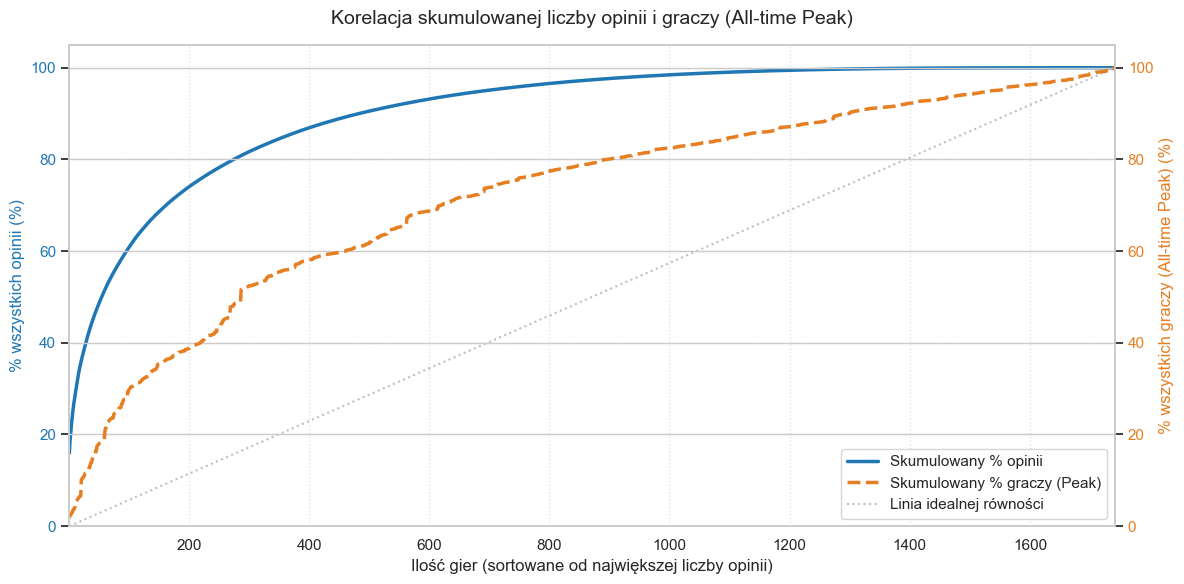

Przykład odcięcia na 1000 grach o największej liczbie opinii:
Odcięty procent opinii: 1.5%
Odcięty procent graczy: 17.5%


In [28]:
### Wykres liniowy skumulowany ###
# Potrzebny posortowany zbiór
df_sorted_stats = df_steam_stats_clean.sort_values(by='total_reviews', ascending=False).reset_index(drop=True)

df_sorted_stats['cumulative_reviews'] = df_sorted_stats['total_reviews'].cumsum()
df_sorted_stats['pct_reviews'] = (df_sorted_stats['cumulative_reviews'] / df_sorted_stats['total_reviews'].sum()) * 100

df_sorted_stats['cumulative_peak'] = df_sorted_stats['all-time_peak'].cumsum()
df_sorted_stats['pct_peak'] = (df_sorted_stats['cumulative_peak'] / df_sorted_stats['all-time_peak'].sum()) * 100

# Zmiana indeksowania z 0-base na 1-base
df_sorted_stats['game_count'] = df_sorted_stats.index + 1

# Wykres
fig, ax1 = plt.subplots(figsize=(12, 6))

# Pierwsza krzywa - skumulowane opinie - lewa oś y
line1 = ax1.plot(
  df_sorted_stats['game_count'], 
  df_sorted_stats['pct_reviews'], 
  color='#1f77b4', 
  linewidth=2.5, 
  label='Skumulowany % opinii'
)
ax1.set_xlabel('Ilość gier (sortowane od największej liczby opinii)', fontsize=12)
ax1.set_ylabel('% wszystkich opinii (%)', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim(0, 105)

# Druga krzywa - skumulowani Gracze - prawa oś y
ax2 = ax1.twinx()  # Tworzymy bliźniaczą oś Y
line2 = ax2.plot(
  df_sorted_stats['game_count'],
  df_sorted_stats['pct_peak'], 
  color='#e67e22', 
  linewidth=2.5, 
  linestyle='--', 
  label='Skumulowany % graczy (Peak)'
)
ax2.set_ylabel('% wszystkich graczy (All-time Peak) (%)', color='#e67e22', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e67e22')
ax2.set_ylim(0, 105)

# Linia odniesienia (x% = y%)
line3 = ax1.plot([1, df_sorted_stats['game_count'].max()], [0, 100], 
                 color='gray', linestyle=':', alpha=0.5, label='Linia idealnej równości')

# Połączenie legend z obu osi w jedno okienko
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=11)

plt.title('Korelacja skumulowanej liczby opinii i graczy (All-time Peak)', fontsize=14, pad=15)
ax1.set_xlim(1, df_sorted_stats['game_count'].max())
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print('='*75)
print('Przykład odcięcia na 1000 grach o największej liczbie opinii:')
print(f'Odcięty procent opinii: {(100 - df_sorted_stats.loc[999, 'pct_reviews']):.1f}%')
print(f'Odcięty procent graczy: {(100 - df_sorted_stats.loc[999, 'pct_peak']):.1f}%')

Z drugiej strony podział na decyle też posiada wady. Występuje w populacji 208 gier, które mają poniżej 10 opinii i są całkowicie wykluczone z klasyfikacji Steam. Jak widać 11.9% gier odpowiada za mniej niż 0.1% wystawionych opinii. Ponadto, tak niski ilość opinii jest bardzo podatna na manipulacje wynikiem. Przy niejednej z tych gier pracowało więcej niż 10 osób, a więc bardzo łatwo byłoby przekonać 9 znajomych lub osoby z rodziny do zakupu gry i wystawienia pozytywnej opinii.

Konieczne jest wykluczenie z populacji gier o bardzo małej ilości opinii, podobnie jak to robi Steam, ale na wyższym progu. Wykres skumulowanej korelacji pokazuje, że skumulowany procent opini odbiega bardziej od linii idealnej równości niż skumulowany procent graczy. To oznacza, że należy być ostrożnym z odciąciem gier o małej ilości opinii bo odcięty ze statystyk zostanie bardziej znaczący odsetek graczy. Przykładowo, odcinając 1.5% opinii z gier o najmniejszej ilości recenzji odcięte zostaje już 17.5% graczy - licząc ilość graczy po szczytowym momencie popularności gry.

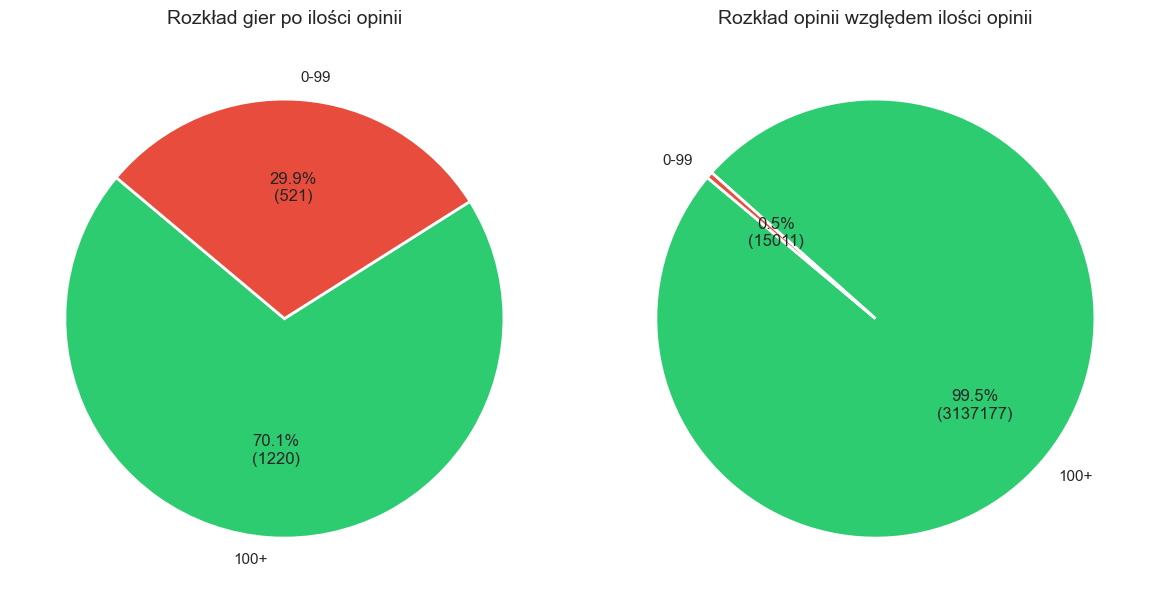

In [29]:
### Wykresy kołowe - ilość opinii v2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Dane
total_games_popular = df_steam_stats_clean[df_steam_stats_clean['total_reviews'] >= 100]['total_reviews'].count()
total_games_not_popular = df_steam_stats_clean[df_steam_stats_clean['total_reviews'] < 100]['total_reviews'].count()

total_reviews_popular = df_steam_stats_clean[df_steam_stats_clean['total_reviews'] >= 100]['total_reviews'].sum()
total_reviews_not_popular = df_steam_stats_clean[df_steam_stats_clean['total_reviews'] < 100]['total_reviews'].sum()

colors = ['#2ecc71', "#e74c3c"]
labels = ['100+', '0-99']

# Wykresy
ax1.pie([total_games_popular, total_games_not_popular], labels=labels, autopct=make_autopct([total_games_popular, total_games_not_popular]), 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Rozkład gier po ilości opinii', fontsize=14, pad=15)

ax2.pie([total_reviews_popular, total_reviews_not_popular], labels=labels, autopct=make_autopct([total_reviews_popular, total_reviews_not_popular]), 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Rozkład opinii względem ilości opinii', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [30]:
print('Porównanie utraty graczy do opinii:')
print(f'Odcięty procent opinii: {(100 - df_sorted_stats.loc[total_games_popular-1, 'pct_reviews']):.1f}%')
print(f'Odcięty procent graczy: {(100 - df_sorted_stats.loc[total_games_popular-1, 'pct_peak']):.1f}%')

Porównanie utraty graczy do opinii:
Odcięty procent opinii: 0.5%
Odcięty procent graczy: 12.3%


Autor zdecydował się na dobór populacji poprzez podział na decyle posortowane po procencie opinii pozytywnych, po wykluczeniu z populacji wszystkich gier z mniej niż 100 opiniami.

Próg 100 opinii został wybrany z trzech powodów. Po pierwsze 100 opinii wciąż da się łatwo zmanipulować, ale już poprzez sam mechanizm wyszukiwarki Steam powinni zacząć pojawiać się prawdziwe opinie. Po drugie przy takim progu wykluczone zostaje prawie 30% gier, co jest już bardzo wysokim wynikiem i może zacząć zmniejszać heterogeniczność próby, całkowicie pomijając opinie reprezentujące 12.3% graczy. Po trzecie maksymalny rozmiar paczki w Steam API wynosi 100, co pomoże ograniczyć w małym stopniu ilość zapytań wysłanych do API.

## Dobór metody próbkowania recenzji
Mając wybraną metodę próbkowania gier należy wybrać metodę próbkowania recenzji dla każdej z gier.

Dobór 1000 opinii z gry, powinien dobrze reprezentować cały zbiór nowszych opinii. Starsze opinie mogą być niewystarczająco reprezentowane, ale żeby utrzymać się przy małej populacji opinii konieczne są uproszczenia. Mimo małej populacji nic nie stoi na przeszkodzie aby wykorzystać metodę, która na odpowiednim komputerze będzie w stanie przygotować próbą o wysokiej jakości statystycznej.

Steam API pozwala na pobór opinii w paczkach o maksymalnym rozmiarze 100 opinii. Ze względu na ograniczenia API nie można "skakać" dowolnie po opiniach, tylko trzeba pobierać opinie używając kursora. Przy każdej odpowiedzi API zwraca kursor, który pozwala na dostęp do kolejnej partii o zdefiniowanym rozmiarze, lecz nie większym niż 100 opinii. Ze względu na ograniczenia techniczne autor pobierze ostatnie 1000 opinii dla każdej gry, jeśli tyle istnieje.

## Losowanie próby gier
Ostateczne kryteria wyboru próby:
* wykluczenie z populacji gier o ilości opinii mniejszej niż 100 gier
* podział pozostałej populacji na decyle uszeregowane po odsetku pozytywnych opinii
* losowy wybór 10 gier z każdego decyla
* wybór ostatniego 1000 opinii dla każdej gry
* łączna maksymalna populacja to 10 decyli * 10 gier * 1000 opinii = 100 tysięcy opinii

Rozmiar próbki będzie zdecydowanie mniejszy, ponieważ wiele gier nie posiada 1000 recenzji.

In [48]:
df_games_population = df_steam_stats_clean[df_steam_stats_clean['total_reviews'] >= 100]
df_games_population['decile'] = pd.qcut(df_games_population['percent_positive'], q=10, labels=False, duplicates='drop') + 1

df_stats_decile_agg_pop = df_games_population.groupby('decile').agg(
  range_min=('percent_positive', 'min'),
  range_max=('percent_positive', 'max'),
  avg_peak=('all-time_peak', 'mean'),
  avg_total_reviews=('total_reviews', 'mean'),
  reviews_min=('total_reviews', 'min'),
  reviews_max=('total_reviews', 'max'),
  avg_positive=('total_positive', 'mean'),
  avg_negative=('total_negative', 'mean')
).reset_index()

# Formatowanie kolumn
stats_to_round = ['avg_peak', 'avg_total_reviews', 'reviews_min', 'reviews_max','avg_positive', 'avg_negative']
df_stats_decile_agg_pop[stats_to_round] = df_stats_decile_agg_pop[stats_to_round].round(0).astype(int)
df_stats_decile_agg_pop['Przedział ocen (%)'] = df_stats_decile_agg_pop.apply(
  lambda row: f"{row['range_min']:.1f}% - {row['range_max']:.1f}%", axis=1
)

# Selekcja i zmiana nazw kolumn do tabeli
df_stats_decile_final_pop = df_stats_decile_agg_pop[[
    'decile', 'Przedział ocen (%)', 'avg_peak','avg_total_reviews', 'reviews_min', 'reviews_max', 'avg_positive', 'avg_negative'
]].rename(columns={
    'decile': 'Decyl',
    'avg_peak': 'Średni Peak Graczy',
    'avg_total_reviews': 'Średnia ilość opinii',
    'reviews_min': 'Minimalna ilość opinii',
    'reviews_max': 'Maksymalna ilość opinii',
    'avg_positive': 'Średnie opinie (+)',
    'avg_negative': 'Średnie opinie (-)'
})

# Wyświetlenie tabeli
print(df_stats_decile_final_pop.to_string(index=False))

 Decyl Przedział ocen (%)  Średni Peak Graczy  Średnia ilość opinii  Minimalna ilość opinii  Maksymalna ilość opinii  Średnie opinie (+)  Średnie opinie (-)
     1      30.1% - 74.6%               90575                  1208                     108                    14055                 786                 422
     2      74.6% - 81.8%               91539                  1291                     102                    17883                1019                 273
     3      81.8% - 86.0%               48777                  1656                     102                    26684                1390                 266
     4      86.1% - 89.6%               68598                  5876                     101                   502009                5138                 738
     5      89.7% - 91.5%               57479                  1668                     100                    26003                1514                 154
     6      91.5% - 93.3%               73760             

In [49]:
# Wybór próbki
sampled_games_list = []
sampled_games_path = '../data/sample_games.csv'

for d in range(1, 11):
    games_subset = df_games_population[df_games_population['decile'] == d]
    game_sample = games_subset.sample(n=10, random_state=42)
    sampled_games_list.append(game_sample)

df_sample_games = pd.concat(sampled_games_list)
df_sample_games.to_csv(sampled_games_path)

# Sprawdzenie
print(df_sample_games['decile'].value_counts().sort_index())
print('='*75)
print('PRÓBA GIER')
print(df_sample_games)

decile
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
Name: count, dtype: int64
PRÓBA GIER
      steam_id                      name  all-time_peak  total_reviews  \
156    1811260        EA SPORTS™ FIFA 23         110878         7392.0   
405    1313860       EA SPORTS™ FIFA 21           44388         2625.0   
411    1501750       Lords of the Fallen          43075          830.0   
1027    844870                  KurtzPel          11937          521.0   
25     3678970        TBH: Task Bar Hero         476577          119.0   
...        ...                       ...            ...            ...   
393     239140               Dying Light          45876        29095.0   
672    1657630           Slime Rancher 2          21524         1545.0   
1471    431730                  Aseprite           6845          221.0   
303     219990                 Grim Dawn          61458         1604.0   
542     221380  Age of Empires II (2013)          27

In [50]:
print(df_sample_games.describe())

           steam_id  all-time_peak  total_reviews  total_positive  \
count  1.000000e+02     100.000000     100.000000      100.000000   
mean   1.159620e+06   61713.010000    2581.860000     2382.020000   
std    9.677437e+05   97582.371918    5145.502596     4987.078352   
min    5.000000e+02    6315.000000     102.000000       57.000000   
25%    3.700675e+05   17356.000000     378.250000      311.250000   
50%    8.723250e+05   27696.500000    1024.000000      929.500000   
75%    1.827165e+06   51492.250000    2422.500000     2200.000000   
max    3.716600e+06  578569.000000   34879.000000    33946.000000   

       total_negative  percent_positive  review_score      decile  
count      100.000000        100.000000    100.000000  100.000000  
mean       199.840000         88.377168      7.830000    5.500000  
std        337.141002          9.832578      1.064154    2.886751  
min          4.000000         47.899160      5.000000    1.000000  
25%         34.000000         83.42321

Wybór próby gier przebiegł pomyślnie.

## Pobieranie opinii

In [51]:
# Utworzenie pustego pliku na opinie jeśli jeszcze nie istnieje
reviews_path_output = '../data/sample_reviews.csv'
df_sample_reviews_empty = pd.DataFrame({}, columns= 
  [
    'game_name',
    'steam_id',
    'recommendationid',
    'author_steamid',
    'playtime_forever',
    'review',
    'voted_up',
    'votes_up',
    'timestamp_created'
  ]
)

def create_sample_reviews_file():
  try:
    df_sample_reviews_empty.to_csv(reviews_path_output, mode='x', index=False)
  except Exception as e:
    print(f'Plik nie został zapisany: {e}')

create_sample_reviews_file()

Plik nie został zapisany: [Errno 17] File exists: '../data/sample_reviews.csv'


In [52]:

# Funkcja do pobrania opinii
def get_game_reviews_details(sample_games, reviews_path_output=reviews_path_output, max_samples=1000, overwrite_existing=False):

  # Zabezpieczenie nadpisu poprzez próbę zapisania/odczytu csv
  if overwrite_existing:
    df_sample_reviews_empty.to_csv(reviews_path_output, mode='w', index=False)
  else:
    try:
      df_reviews_source = pd.read_csv(reviews_path_output)
      if len(df_reviews_source) > 0:
        sys.exit('Plik z próbą opinii istnieje. Jeśli chcesz nadpisać użyj parametru funkcji "overwrite_existing=true"')
    except:
      create_sample_reviews_file()
  
  df_reviews_source = df_sample_reviews_empty.copy()

  games_tuple = sample_games.apply(lambda row: row.to_dict(), axis=1)

  headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
  }
  
  # Parametry API Steam dla pobierania samych recenzji
  base_params = {
    'json': 1,
    'filter': 'recent',
    'language': 'polish',
    'num_per_page': 100,
    'review_type': 'all',
    'purchase_type': 'all'
  }

  batch_new_reviews = []
  rate_limit_hits = 0
  max_rate_hits = 5
  initial_sleep = 2
  
  gdx = 0
  total_games = len(games_tuple)
  print(total_games)

  for game in games_tuple:
    
    game_name = game['name']
    game_id = game['steam_id']
    total_reviews = game['total_reviews']
    gdx += 1
    print(f'\n=== [{gdx}/{total_games}] Rozpoczęcie pobierania recenzji dla Gry ID: {game_id}')
    
    cursor = '*'  # Początkowy cursor dla nowej gry
    reviews_fetched_for_game = 0
    batch_new_reviews = []
    
    while reviews_fetched_for_game < max_samples:
      url = f'https://store.steampowered.com/appreviews/{game_id}'
      
      params = base_params.copy()
      params['cursor'] = cursor # aktualizacja na końcu pętli
      
      try:
        response = requests.get(url, headers=headers, params=params, timeout=10)

        # Obsługa Rate Limit (HTTP 429)
        if response.status_code == 429:
          if rate_limit_hits < max_rate_hits:
            rate_limit_hits += 1
            sleep_time = initial_sleep * (2 ** rate_limit_hits)
            print(f'STOP! Rate limit (429). Zasypiam na {sleep_time}s...')
            time.sleep(sleep_time)
            continue  # Powtórka pętli while do końca kursora
          else:
            print('Przekroczono limity zapytań. Awaryjny zapis zebranych danych...')
            break # Koniec pętli i zapis opinii

        if response.status_code == 200:
          data = response.json()
          
          if data.get('success') != 1:
            print(f'Steam zwrócił success=0 dla ID {game_id}. Spróbuj ponownie pobrać opinie dla gry później. Przejście do kolejnej gry...')
            break
          
          reviews = data.get('reviews', [])
          if not reviews:
            print(f'Brak kolejnych recenzji dla ID {game_id}.')
            break
          
          # Parsowanie otrzymanych recenzji
          for rev in reviews:
            batch_new_reviews.append({
              'game_name': game_name,
              'steam_id': game_id,
              'recommendationid': str(rev.get('recommendationid')),
              'author_steamid': rev.get('author', {}).get('steamid'),
              'playtime_forever': rev.get('author', {}).get('playtime_forever'),
              'review': rev.get('review', ''),
              'voted_up': rev.get('voted_up'), # True/False
              'votes_up': rev.get('votes_up', 0),
              'timestamp_created': rev.get('timestamp_created')
            })
          
          reviews_fetched_for_game += len(reviews)
          print(f'-> Pobrano {reviews_fetched_for_game}/{max_samples} recenzji...')
          
          # Pobranie nowego cursora do kolejnej paczki
          next_cursor = data.get('cursor')
          if not next_cursor or next_cursor == cursor:
            break
          cursor = next_cursor
          
          # Reset licznika rate limitów po udanym zapytaniu
          rate_limit_hits = max(0, rate_limit_hits - 1) # Dużo zapytań, tak bezpieczniej niż zwykły reset do 0
          
        else:
          print(f'Błąd HTTP {response.status_code} dla ID {game_id}. Spróbuj ponownie pobrać opinie dla gry później. Przejście do kolejnej gry...')
          break

      except Exception as e:
        print(f'Nieoczekiwany błąd przy pobieraniu opinii dla ID {game_id}: {e}')
        break
      
      # Przerwa dla API
      time.sleep(0.2)
      
    if rate_limit_hits >= max_rate_hits:
      break

    if batch_new_reviews:
      df_reviews_source = pd.concat([df_reviews_source, pd.DataFrame(batch_new_reviews)], ignore_index=True)
      df_reviews_source.to_csv(reviews_path_output, mode='w', index=False)
      print(f'Wybrano {len(batch_new_reviews)} dla gry {game_id}...')
  
  print(f'Plik zaktualizowany. Łączna liczba recenzji w bazie: {len(df_reviews_source)}')

In [53]:
df_sampled_games_read = pd.read_csv(sampled_games_path)
# Pobrano 72158 opinii w 15m 2s
get_game_reviews_details(df_sampled_games_read, overwrite_existing=True)

100

=== [1/100] Rozpoczęcie pobierania recenzji dla Gry ID: 1811260
-> Pobrano 100/1000 recenzji...
-> Pobrano 200/1000 recenzji...
-> Pobrano 300/1000 recenzji...
-> Pobrano 400/1000 recenzji...
-> Pobrano 500/1000 recenzji...
-> Pobrano 600/1000 recenzji...
-> Pobrano 700/1000 recenzji...
-> Pobrano 800/1000 recenzji...
-> Pobrano 900/1000 recenzji...
-> Pobrano 1000/1000 recenzji...
Wybrano 1000 dla gry 1811260...

=== [2/100] Rozpoczęcie pobierania recenzji dla Gry ID: 1313860
-> Pobrano 100/1000 recenzji...
-> Pobrano 200/1000 recenzji...
-> Pobrano 300/1000 recenzji...
-> Pobrano 400/1000 recenzji...
-> Pobrano 500/1000 recenzji...
-> Pobrano 600/1000 recenzji...
-> Pobrano 700/1000 recenzji...
-> Pobrano 800/1000 recenzji...
-> Pobrano 900/1000 recenzji...
-> Pobrano 1000/1000 recenzji...
Wybrano 1000 dla gry 1313860...

=== [3/100] Rozpoczęcie pobierania recenzji dla Gry ID: 1501750
-> Pobrano 100/1000 recenzji...
-> Pobrano 200/1000 recenzji...
-> Pobrano 300/1000 recenzji...

Próbka opinii została pobrana z powodzeniem. Na tym etapie próbka nie jest analizowana, żeby ograniczyć stronniczość przy trenowaniu modelu.

## Trenowanie modelu uczenia maszynowego

Zbiór opinii jest skomplikowany dla modelów, ponieważ posiada mnóstwo zapożyczeń z języków obcych, slangu, wulgaryzmów, literówek i celowych ciągów wpisanych losowo. Ponadto w tej sekcji będzie widoczne jak poważnym problemem jest niezrównoważenie klas. Zdecydowano się na wytrenowanie modeli za pomocą wektoryzatorów TF-IDF oraz Bag of Words.



Najpierw ze zbioru opinii wykluczane są opinie składające się z jednego znaku lub żadnych. Nie mają one żadnej wartości dodanej dla modelu.

In [137]:
df_reviews_dirty = pd.read_csv("../data/sample_reviews.csv")

df_reviews_clean = df_reviews_dirty.copy()
df_reviews_clean = df_reviews_clean[df_reviews_clean['review'].str.len() >= 2]
print(f'Usunięto {len(df_reviews_dirty) - len(df_reviews_clean)} opinii')

df_reviews_clean['voted_down'] = (1 - df_reviews_clean['voted_up'].astype(int))

Usunięto 2567 opinii


Najistotniejszym wskaźnikiem dla trenowanych modeli jest `recall`, czyli czułość. Przez to, że wielkość klas jest bardzo dysproporcjonalna, istnieje bardzo duże ryzyko, że model nauczy się zawsze zgadywać opinię pozytywną. Osoba, która bez żadnego algorytmu zakładałaby zawsze opinię pozytywną, byłaby w stanie osiągnąć dokładność (`accuracy`) koło 90%.

Priorytetem jest zatem uzyskanie relatywnie wysokiego czułości, utrzymując dokładność, oraz precyzję. Autor stara się aby zawsze uzyskać czułość oraz precyzja wynosiły co najmniej 60%.

Modele najpierw zostaną obliczone, a później wspólnie opisane.

In [150]:
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
### TF-IDF ###

# Przygotowanie danych - wektoryzacja
vectorizer = TfidfVectorizer(max_features=5000, stop_words=None)

X_tfidf = vectorizer.fit_transform(df_reviews_clean['review']).toarray()

X_train_tfidf, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, df_reviews_clean['voted_up'], test_size=0.2, random_state=42
)

y_train_np_tfidf = np.array(y_train)
y_test_np_tfidf = np.array(y_test)

# Architektura modelu TF-IDF
model_tfidf = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.5), 
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Kompilacja
model_tfidf.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_recall', 
    patience=3,           
    mode='max',           
    restore_best_weights=True 
)

# Trening modelu
print("Trwa trening sieci opartej na TF-IDF...")
history_tfidf = model_tfidf.fit(
    X_train_tfidf, y_train_np_tfidf,   
    epochs=20,            
    batch_size=32,        
    validation_split=0.1, 
    callbacks=[early_stop], 
    verbose=1
)

loss_tfidf, accuracy_tfidf, precision_tfidf, recall_tfidf = model_tfidf.evaluate(X_test_tfidf, y_test_np_tfidf, verbose=0)
print(f"\n[TF-IDF] Dokładność: {accuracy_tfidf:.4f}")
print(f"\n[TF-IDF] Precyzja: {precision_tfidf:.4f}")
print(f"\n[TF-IDF] Czułość: {recall_tfidf:.4f}")
print(f"\n[TF-IDF] Strata: {loss_tfidf:.4f}")

Trwa trening sieci opartej na TF-IDF...
Epoch 1/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9083 - loss: 0.2359 - precision: 0.9217 - recall: 0.9799 - val_accuracy: 0.9197 - val_loss: 0.2057 - val_precision: 0.9286 - val_recall: 0.9847
Epoch 2/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9357 - loss: 0.1723 - precision: 0.9494 - recall: 0.9797 - val_accuracy: 0.9222 - val_loss: 0.2039 - val_precision: 0.9397 - val_recall: 0.9744
Epoch 3/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9465 - loss: 0.1470 - precision: 0.9576 - recall: 0.9833 - val_accuracy: 0.9212 - val_loss: 0.2124 - val_precision: 0.9397 - val_recall: 0.9731
Epoch 4/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9567 - loss: 0.1232 - precision: 0.9651 - recall: 0.9869 - val_accuracy: 0.9197 - val_loss: 0.2367 - val_precision: 0.9356 - val_recall: 0.9762

[TF-IDF] Dokładność: 0.9282

[TF-IDF] Precyzja: 0.9380

[TF-IDF] Czułość: 0.9847

[TF-IDF] Strata: 0.19

Model ma bardzo wysoką czułość 

In [ ]:
### Word2Vec ###

# Przygotowanie - tokenizacja
print("Tokenizacja tekstu...")
tokenized_reviews = [review.lower().split() for review in df_reviews_clean['review']]

# Trening modelu
print("Trenowanie modelu Word2Vec...")
w2v_model = Word2Vec(
    sentences=tokenized_reviews, 
    vector_size=100, 
    window=5, 
    min_count=2, 
    workers=4
)

# Wektoryzacja
def get_review_vector(tokens, model):
    # Tylko znane słowa dla W2V zna
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        # Jeśli brak znanych słów, zwracamy wektor samych zer
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

print("Generowanie embeddingów W2V dla wszystkich recenzji...")
X_w2v = np.array([get_review_vector(tokens, w2v_model) for tokens in tokenized_reviews])

y_w2v = np.array(df_reviews_clean['voted_up'])

X_train_w2v, X_test_w2v, y_train_np_w2v, y_test_np_w2v = train_test_split(
    X_w2v, y_w2v, test_size=0.2, random_state=42
)

# Architektura sieci
model_w2v = Sequential([
    # Input shape dopasowany do rozmiaru wektora W2V (100)
    Dense(128, activation='relu', input_shape=(X_train_w2v.shape[1],)),
    Dropout(0.4), # Wyższy dropout, żeby sieć nie "zgadywała" na oślep i poprawiła Precision
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Dodajemy Precision i Recall do metryk, żeby widzieć problem jak na dłoni
model_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=4, 
    restore_best_weights=True
)

# Trening modelu
print("Trwa trening sieci opartej na W2V...")
history = model_w2v.fit(
    X_train_w2v, y_train_np_w2v,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

loss_w2v, accuracy_w2v, precision_w2v, recall_w2v = model_w2v.evaluate(X_test_w2v, y_test_np_w2v, verbose=0)
print(f"\n[Word2Vec] Dokładność: {accuracy_w2v:.4f}")
print(f"\n[Word2Vec] Precyzja: {precision_w2v:.4f}")
print(f"\n[Word2Vec] Czułość: {recall_w2v:.4f}")
print(f"\n[Word2Vec] Strata: {loss_w2v:.4f}")

Tokenizacja tekstu...
Trenowanie modelu Word2Vec...
Generowanie embeddingów W2V dla wszystkich recenzji...


c:\Users\karol\repos\dsai-final-project\.venv_keras\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trwa trening sieci opartej na W2V...
Epoch 1/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8865 - loss: 0.3005 - precision: 0.8895 - recall: 0.9958 - val_accuracy: 0.8829 - val_loss: 0.2845 - val_precision: 0.8874 - val_recall: 0.9933
Epoch 2/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8886 - loss: 0.2805 - precision: 0.8915 - recall: 0.9956 - val_accuracy: 0.8838 - val_loss: 0.2786 - val_precision: 0.8904 - val_recall: 0.9902
Epoch 3/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8900 - loss: 0.2767 - precision: 0.8938 - recall: 0.9941 - val_accuracy: 0.8843 - val_loss: 0.2764 - val_precision: 0.8863 - val_recall: 0.9967
Epoch 4/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8921 - loss: 0.2725 - precision: 0.8978 - recall: 0.9913 - val_accuracy: 0.8845 - val_loss: 0.2770 - val_precision: 0.8869 - val_recall: 0.9961
Epoch 5/20
1566/1566 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8918 - loss: 0.2686 - precision: 0.8988 - rec

In [208]:
# 1. Uzyskaj predykcje
y_pred_w2v = (model_w2v.predict(X_test_w2v) > 0.7).astype(int) # Użyj swojego wybranego progu
y_pred_tfidf = (model_tfidf.predict(X_test_tfidf) > 0.7).astype(int)

# 2. Wygeneruj raporty
rep_w2v = classification_report(y_test_np_w2v, y_pred_w2v, output_dict=True)
rep_tfidf = classification_report(y_test_np_tfidf, y_pred_tfidf, output_dict=True)

# Porównanie modeli
df_compare = pd.DataFrame({
    'W2V Precision': [rep_w2v['False']['precision'], rep_w2v['True']['precision'], rep_w2v['macro avg']['precision']],
    'W2V Recall':    [rep_w2v['False']['recall'], rep_w2v['True']['recall'], rep_w2v['macro avg']['recall']],
    'W2V F1-Score':  [rep_w2v['False']['f1-score'], rep_w2v['True']['f1-score'], rep_w2v['macro avg']['f1-score']],
    'TF-IDF Precision': [rep_tfidf['False']['precision'], rep_tfidf['True']['precision'], rep_tfidf['macro avg']['precision']],
    'TF-IDF Recall':    [rep_tfidf['False']['recall'], rep_tfidf['True']['recall'], rep_tfidf['macro avg']['recall']],
    'TF-IDF F1-Score':  [rep_tfidf['False']['f1-score'], rep_tfidf['True']['f1-score'], rep_tfidf['macro avg']['f1-score']]
}, index=['Klasa Negatywna (1)', 'Klasa Pozytywna (0)','Średnia (Macro)'])

print("=== ZESTAWIENIE METRYK ===")
print(df_compare.round(2))

435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
=== ZESTAWIENIE METRYK ===
                     W2V Precision  W2V Recall  W2V F1-Score  \
Klasa Negatywna (1)           0.48        0.50          0.49   
Klasa Pozytywna (0)           0.94        0.94          0.94   
Średnia (Macro)               0.71        0.72          0.71   

                     TF-IDF Precision  TF-IDF Recall  TF-IDF F1-Score  
Klasa Negatywna (1)              0.63           0.63             0.63  
Klasa Pozytywna (0)              0.96           0.96             0.96  
Średnia (Macro)                  0.79           0.79             0.79  


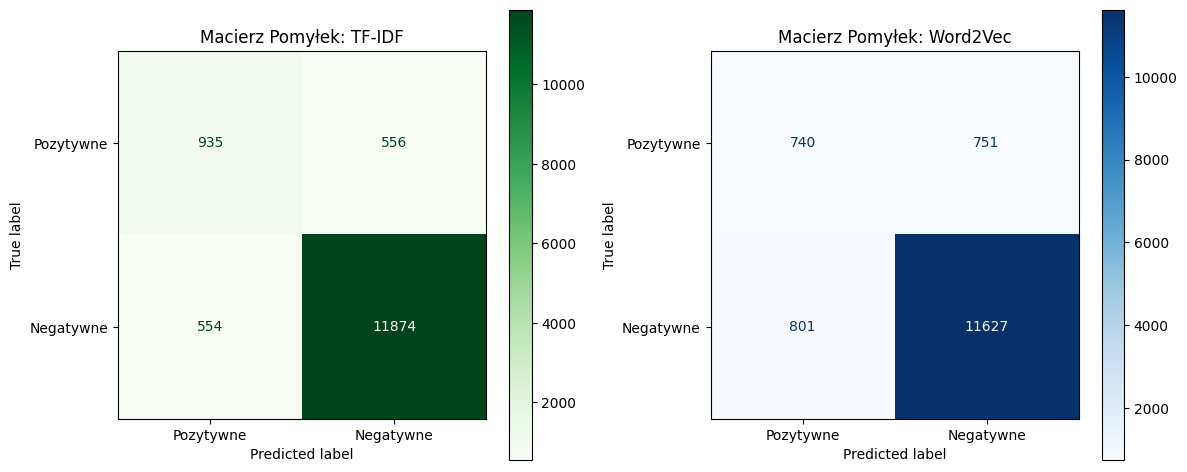

In [209]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Macierz TF-IDF
cm_tfidf = confusion_matrix(y_test_np_tfidf, y_pred_tfidf)
ConfusionMatrixDisplay(cm_tfidf, display_labels=['Pozytywne', 'Negatywne']).plot(ax=axes[0], cmap='Greens')
axes[0].set_title('Macierz Pomyłek: TF-IDF')

# Macierz W2V
cm_w2v = confusion_matrix(y_test_np_w2v, y_pred_w2v)
ConfusionMatrixDisplay(cm_w2v, display_labels=['Pozytywne', 'Negatywne']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Macierz Pomyłek: Word2Vec')

plt.tight_layout()
plt.show()

Z dwóch porównywanych modeli TF-IDF jest zdecydowanie lepszy. TF-IDF ma czułość oraz precyzję dla klasy negatywnej na poziomie 63%, czyli można już stwierdzić, że model ma wartość statystyczną. Przez niezbalansowane klasy oba modele wymagały korekty progu predykcji. W obu modelach ten zabieg stworzył dobry kompromis między precyzją a czułością, chociaż w Word2Vec ma wskaźniki na zbyt niskim poziomie aby model miał jakąkolwiek wartość.

## Wnioski

Podsumowując projekt należy podzielić go na dwie części. Pierwsza część związana z data pipeline aż do wyboru opinii z gier należy uznać za sukces. Udało się pobrać istotną ilość danch, szanując limity Steam. Dodatkowo proces jest skalowalny. Jedynym krokiem pozostałym do poprawy byłaby pierwotna selekcja gier. Pobranie strony SteamDB nie jest bardzo uciążliwe, ale nie jest pełną automatyzacją. Istnieją endpointy Steam, które możnaby wykorzystać w przyszłości, chociaż nie są tak wygodne w obsłudze jak strona SteamDB.

Druga część projektu jest ograniczonym sukcesem. Wytrenowane modele Word2Vec oraz TF-IDF pokazują, że zbiór danych nie jest łatwy do predykcji, ale jest możliwość zastosowania algorytmów uczenia maszynowego do oszacowania przynajmniej części opinii gier na Steam. Zwiększenie próby mogłoby pomóc w poprawie wyników, co nie zmienia faktu, że zbiór jest bardzo niezbalansowany, a język wykorzystywany przez graczy daleki od poprawnej polszczyzny.

Istnieją możliwości dalszego rozwoju modeli uczenia maszynowego. Możnaby wprowadzić bardziej zaawansowaną tokenizację, która doprowadziłaby większą ilość słów to wspólnej formy. Ponadto są jeszcze możliwości poprawy hiperparametryzacji. Dodatkowo możnaby spróbować jeszcze inne metody wektoryzacji.

Podsumowując, chociaż wyniki nie są w tym momencie w pełni zadowalające, to powstał proces, który może być wykorzystywany do dalszych badań - od wyboru gier do próby po wytrenowanie modelu uczenia maszynowego.